In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

df = pd.read_parquet('data.parquet')

In [3]:
df.iloc[10]


pos_x                      3.827243
pos_y                      3.929089
pos_z                     -0.806034
nvoxels                       252.0
template_x                -0.291847
template_y                 -6.43448
template_z                 4.081269
stain                         Abeta
sdt_CD31                   0.001586
index                          1042
name              left Lobules IV-V
subject                  sub-AS40F2
participant_id           sub-AS40F2
lightsheet_id                     a
genotype                      ApoE4
sex                               F
treatment                       PBS
sdt_CD31_um                1.585558
plaque_vol_um3              1774.08
plaque_vol_ml              0.000002
equiv_diam_um             15.019594
Name: 10, dtype: object

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# Parameters you may want to change
# =========================================================
VOL_THRESH_ML = 1e-4          # remove implausibly large plaques
TAU_UM = 5.0                 # "near vessel" threshold in microns
VESSEL_BINS_UM = (0, 10, 20, np.inf)
VESSEL_BIN_LABELS = ("<10 µm", "10-20 µm", ">20 µm")


# =========================================================
# Core processing
# =========================================================
def prepare_plaque_dataframe(
    df,
    vol_thresh_ml=VOL_THRESH_ML,
    tau_um=TAU_UM,
    vessel_bins_um=VESSEL_BINS_UM,
    vessel_bin_labels=VESSEL_BIN_LABELS,
    vol_col="plaque_vol_ml",
    sdt_col_mm="sdt_CD31",
    plaque_diam_col="equiv_diam_um",
):
    """
    Steps:
      1) remove very large plaques
      2) convert sdt from mm to um
      3) classify plaque-vessel relation into 3 classes
      4) for plaques with sdt_um < 0, estimate minimum compatible vessel diameter
      5) bin that estimated vessel diameter
    """
    out = df.loc[df[vol_col] <= vol_thresh_ml].copy()

    # convert mm -> um
    out["sdt_um"] = out[sdt_col_mm] * 1000.0

    # 3 classes
    out["vessel_relation"] = pd.cut(
        out["sdt_um"],
        bins=[-np.inf, 0, tau_um, np.inf],
        labels=[
            "within/overlapping vessel",
            f"near vessel (0–{tau_um:g} µm)",
            f"far from vessel (>{tau_um:g} µm)",
        ],
        include_lowest=True,
        right=True,
    )

    # for sdt < 0:
    # min_vessel_diam_um = plaque_diam_um - 2*sdt_um
    # since sdt_um is negative inside vessels, this becomes plaque_diam + 2*abs(sdt)
    out["min_vessel_diam_um"] = np.nan
    inside = out["sdt_um"] < 0
    out.loc[inside, "min_vessel_diam_um"] = (
        out.loc[inside, plaque_diam_col] - 2 * out.loc[inside, "sdt_um"]
    )

    # bin estimated minimum vessel diameter
    out["vessel_diam_bin"] = pd.cut(
        out["min_vessel_diam_um"],
        bins=vessel_bins_um,
        labels=vessel_bin_labels,
        include_lowest=True,
        right=False,
    )

    return out


df = prepare_plaque_dataframe(df)

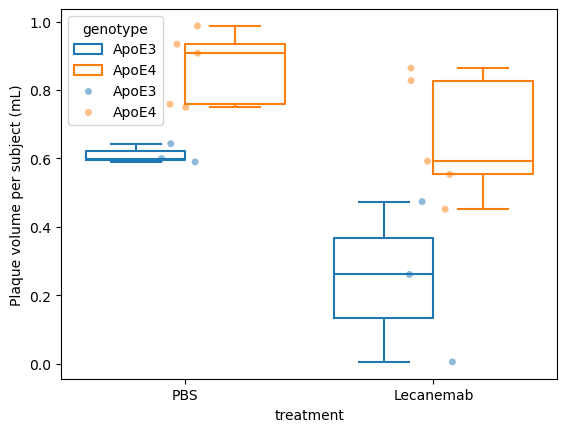

In [110]:
counts = (
    df.groupby(['subject', 'treatment', 'sex', 'genotype'])['plaque_vol_ml']
      .sum()
      .reset_index(name='plaque_vol_um3')
)
plt.figure()
sns.boxplot(data=counts, x='treatment', y='plaque_vol_um3',hue='genotype',fill=False)
sns.stripplot(data=counts, x='treatment', y='plaque_vol_um3',hue='genotype', alpha=0.5)
plt.ylabel("Plaque volume per subject (mL)")
plt.show()

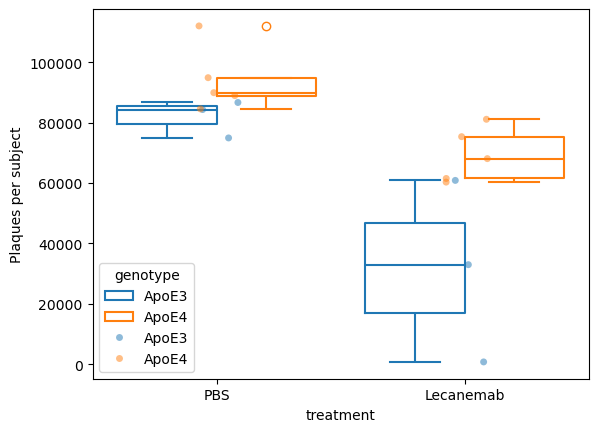

In [111]:
counts = df.groupby(['subject', 'treatment','sex','genotype']).size().reset_index(name='n_plaques')

plt.figure()
sns.boxplot(data=counts, x='treatment', y='n_plaques',hue='genotype',fill=False)
sns.stripplot(data=counts, x='treatment', y='n_plaques',hue='genotype', alpha=0.5)
plt.ylabel("Plaques per subject")
plt.show()

## updated code to get vessel * plaque relationships

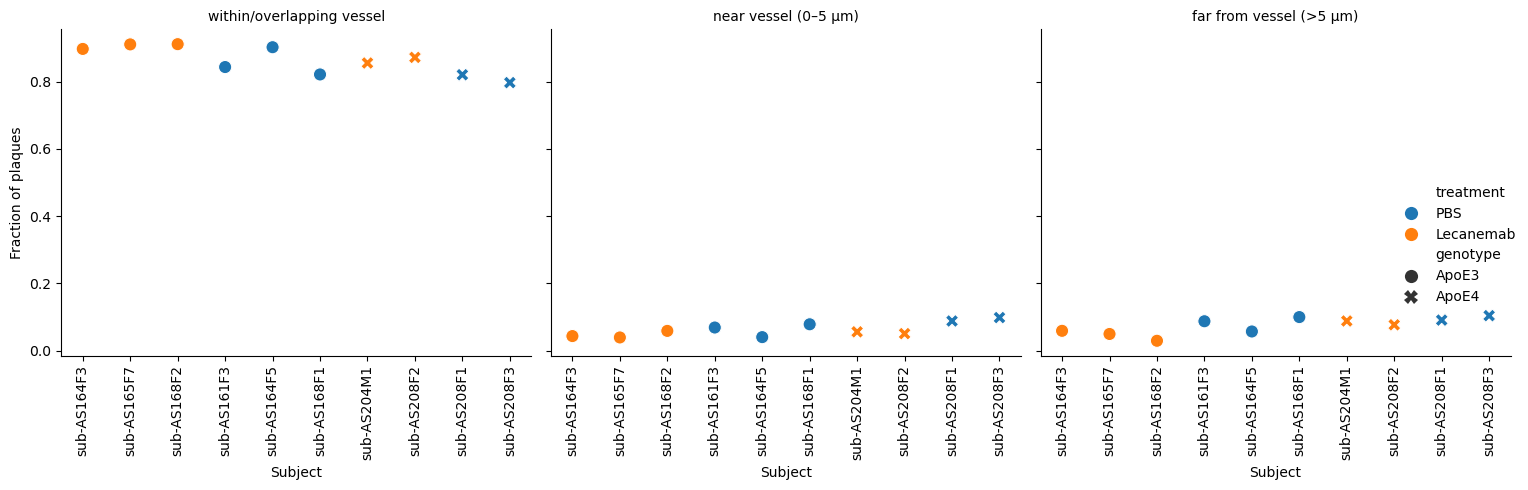

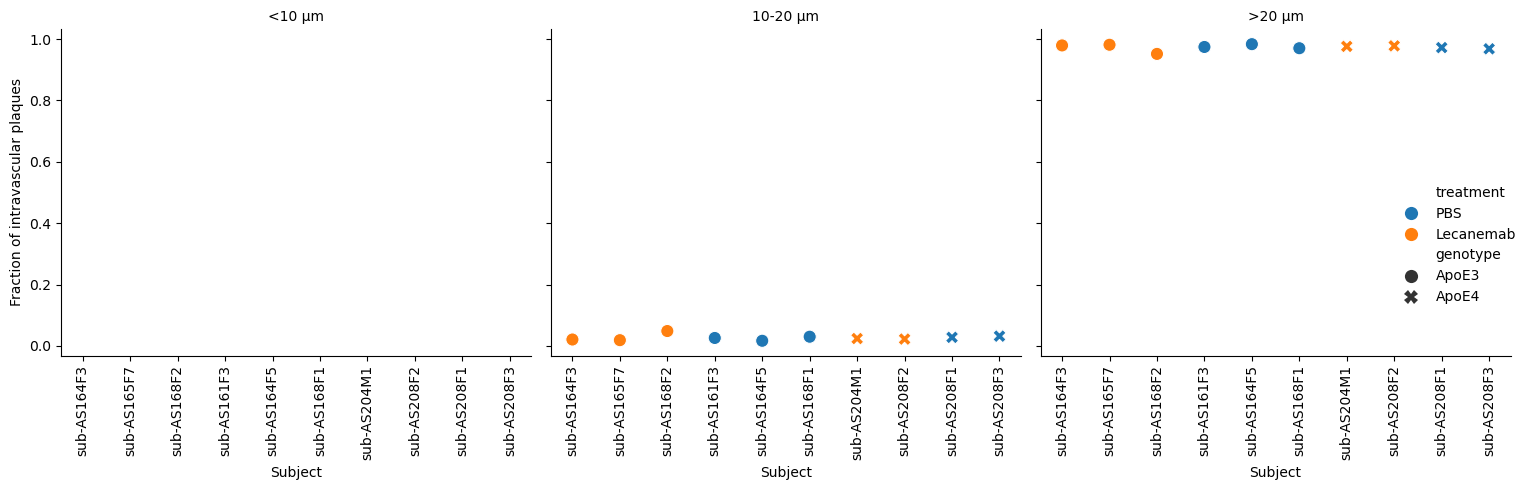

In [42]:
# =========================================================
# Subject-level summaries
# =========================================================
def summarize_subject_proximity(
    plaque_df,
    subject_col="subject",
    group_cols=("genotype", "treatment"),
):
    """
    Per-subject fractions of plaques in the 3 vessel-relation classes.
    """
    id_cols = [subject_col] + list(group_cols)

    counts = (
        plaque_df.groupby(id_cols + ["vessel_relation"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )

    totals = (
        plaque_df.groupby(id_cols, observed=True)
        .size()
        .rename("n_total")
        .reset_index()
    )

    out = counts.merge(totals, on=id_cols, how="left")
    out["fraction"] = out["n"] / out["n_total"]
    out["percent"] = 100 * out["fraction"]
    return out


def summarize_subject_vessel_diam(
    plaque_df,
    subject_col="subject",
    group_cols=("genotype", "treatment"),
):
    """
    Per-subject fractions of estimated vessel diameter bins,
    restricted to plaques with sdt_um < 0.
    """
    id_cols = [subject_col] + list(group_cols)

    inside = plaque_df.loc[plaque_df["sdt_um"] < 0].copy()

    counts = (
        inside.groupby(id_cols + ["vessel_diam_bin"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )

    totals = (
        inside.groupby(id_cols, observed=True)
        .size()
        .rename("n_inside_total")
        .reset_index()
    )

    out = counts.merge(totals, on=id_cols, how="left")
    out["fraction"] = out["n"] / out["n_inside_total"]
    out["percent"] = 100 * out["fraction"]
    return out


# =========================================================
# Plotting
# =========================================================
def _subject_order(df, subject_col="subject"):
    meta = df[[subject_col, "genotype", "treatment"]].drop_duplicates().copy()
    meta = meta.sort_values(["genotype", "treatment", subject_col])
    return meta[subject_col].tolist()


def plot_subject_proximity(
    subject_proximity,
    subject_col="subject",
    figsize=(14, 5),
):
    """
    One point per subject per plaque-vessel class.
    Color = genotype, style = treatment, facet = class.
    """
    order = _subject_order(subject_proximity, subject_col=subject_col)

    plot_df = subject_proximity.copy()
    plot_df[subject_col] = pd.Categorical(plot_df[subject_col], categories=order, ordered=True)

    g = sns.relplot(
        data=plot_df,
        x=subject_col,
        y="fraction",
        style="genotype",
        hue="treatment",
        col="vessel_relation",
        kind="scatter",
        col_wrap=3,
        height=figsize[1],
        aspect=figsize[0] / (3 * figsize[1]),
        s=90,
    )

    g.set_axis_labels("Subject", "Fraction of plaques")
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()


def plot_subject_vessel_diam(
    subject_vessel_diam,
    subject_col="subject",
    figsize=(14, 5),
):
    """
    One point per subject per estimated vessel diameter bin.
    Color = genotype, style = treatment, facet = vessel diameter bin.
    """
    order = _subject_order(subject_vessel_diam, subject_col=subject_col)

    plot_df = subject_vessel_diam.copy()
    plot_df[subject_col] = pd.Categorical(plot_df[subject_col], categories=order, ordered=True)

    g = sns.relplot(
        data=plot_df,
        x=subject_col,
        y="fraction",
        style="genotype",
        hue="treatment",
        col="vessel_diam_bin",
        kind="scatter",
        col_wrap=3,
        height=figsize[1],
        aspect=figsize[0] / (3 * figsize[1]),
        s=90,
    )

    g.set_axis_labels("Subject", "Fraction of intravascular plaques")
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()


# =========================================================
# One function to run everything
# =========================================================
def run_plaque_vessel_analysis(
    df,
    vol_thresh_ml=VOL_THRESH_ML,
    tau_um=TAU_UM,
    vessel_bins_um=VESSEL_BINS_UM,
    vessel_bin_labels=VESSEL_BIN_LABELS,
    subject_col="subject",
    group_cols=("genotype", "treatment"),
):
    plaque_df = prepare_plaque_dataframe(
        df,
        vol_thresh_ml=vol_thresh_ml,
        tau_um=tau_um,
        vessel_bins_um=vessel_bins_um,
        vessel_bin_labels=vessel_bin_labels,
    )

    subject_proximity = summarize_subject_proximity(
        plaque_df,
        subject_col=subject_col,
        group_cols=group_cols,
    )

    subject_vessel_diam = summarize_subject_vessel_diam(
        plaque_df,
        subject_col=subject_col,
        group_cols=group_cols,
    )

    return plaque_df, subject_proximity, subject_vessel_diam


# =========================================================
# Example usage
# =========================================================
# df = pd.read_csv("your_file.csv")   # or however you load it

plaque_df, subject_proximity, subject_vessel_diam = run_plaque_vessel_analysis(df)

plot_subject_proximity(subject_proximity)
plot_subject_vessel_diam(subject_vessel_diam)

## 1️⃣ Compare plaque size distributions

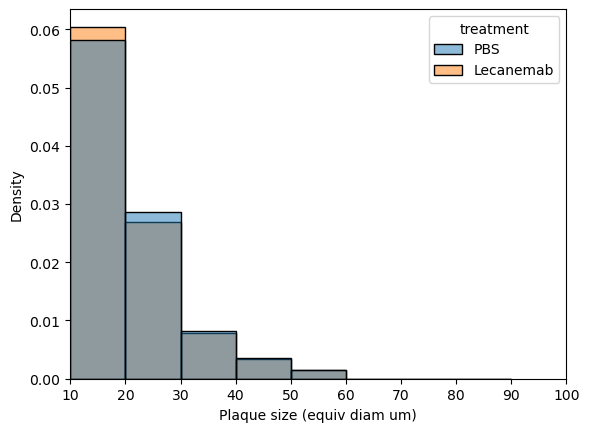

In [43]:
plt.figure()
sns.histplot(data=df, x='equiv_diam_um', hue='treatment', bins=np.arange(10,100,10), log_scale=False, stat='density', common_norm=False)
plt.xlim((10,100))
plt.xlabel("Plaque size (equiv diam um)")
plt.show()

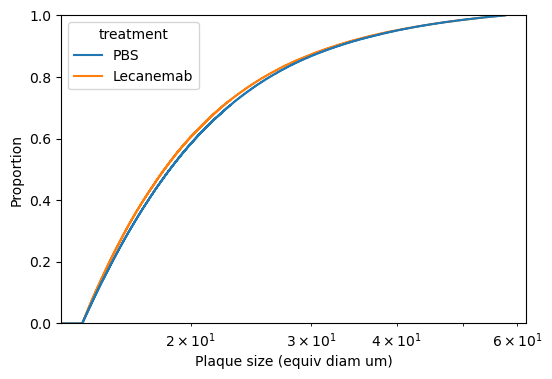

In [44]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="equiv_diam_um",
    hue="treatment"
)

plt.xscale("log")
plt.xlabel("Plaque size (equiv diam um)")
plt.show()

## 2️⃣ Distance to vessel distribution


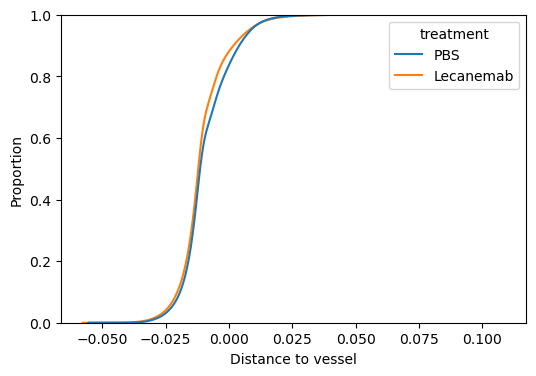

In [45]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="sdt_CD31",
    hue="treatment"
)

plt.xlabel("Distance to vessel")
plt.show()

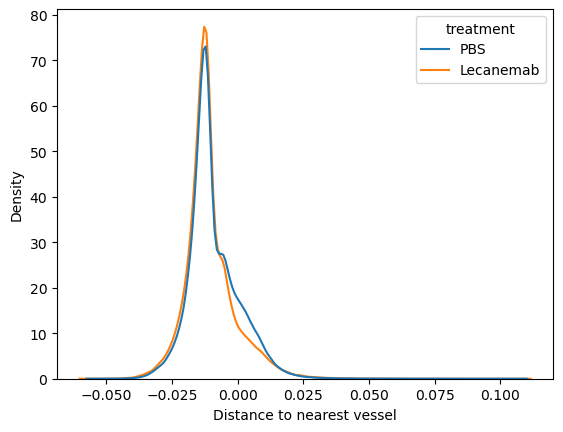

In [46]:
plt.figure()
sns.kdeplot(data=df, x='sdt_CD31', hue='treatment', common_norm=False)
plt.xlabel("Distance to nearest vessel")
plt.show()

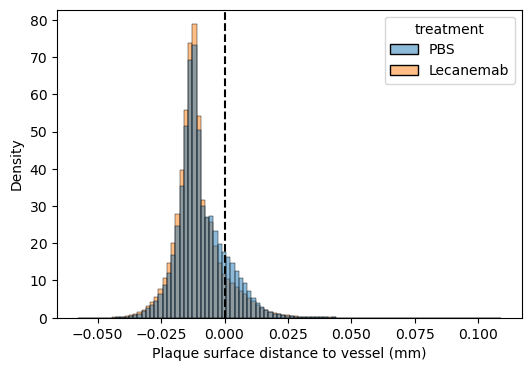

In [47]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="sdt_CD31",
    hue="treatment",
    bins=100,
    stat="density",
    common_norm=False
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.show()

In [17]:
df["touching_vessel"] = df["sdt_CD31"] <= 0

df.groupby("treatment")["touching_vessel"].mean()

treatment
Lecanemab    0.907811
PBS          0.847970
Name: touching_vessel, dtype: float64

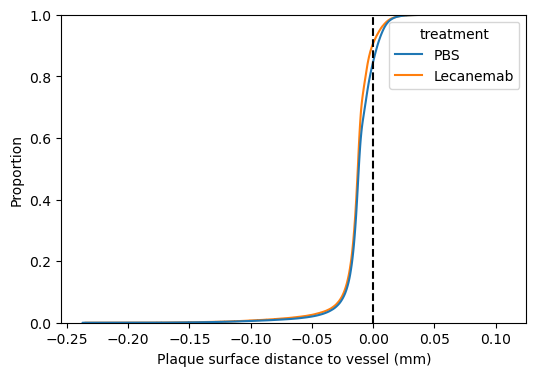

In [18]:
plt.figure(figsize=(6,4))

sns.ecdfplot(
    data=df,
    x="sdt_CD31",
    hue="treatment"
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.show()

## 3️⃣ Size vs vessel distance - not sure what to make of this one..

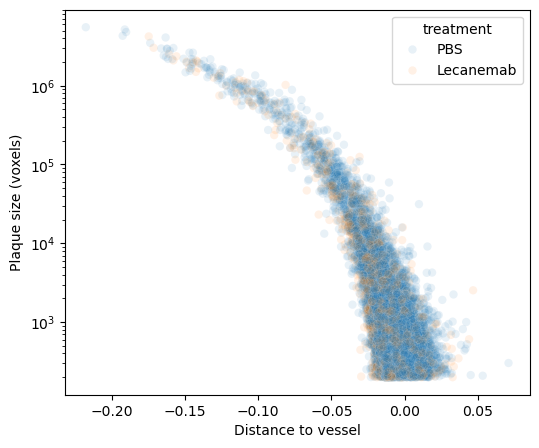

In [19]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="nvoxels",
    hue="treatment",
    alpha=0.1
)

plt.yscale("log")
plt.xlabel("Distance to vessel")
plt.ylabel("Plaque size (voxels)")
plt.show()

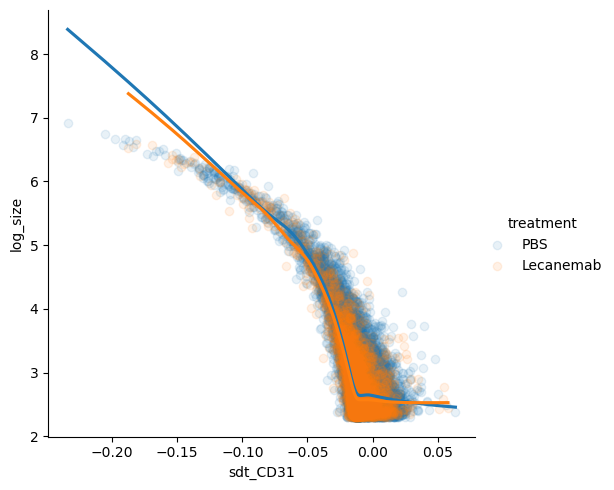

In [20]:
sns.lmplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="log_size",
    hue="treatment",
    scatter_kws={'alpha':0.1},
    lowess=True
)

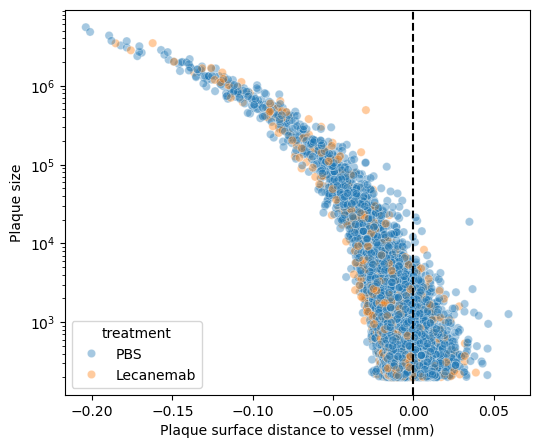

In [52]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(20000),
    x="sdt_CD31",
    y="nvoxels",
    hue="treatment",
    alpha=0.4
)

plt.yscale("log")
plt.axvline(0,color="black",ls="--")
plt.xlabel("Plaque surface distance to vessel (mm)")
plt.ylabel("Plaque size")
plt.show()

In [ ]:
conditions = [
    df["sdt_CD31"] < 0,
    (df["sdt_CD31"] >= 0) & (df["sdt_CD31"] < 0.1),
    df["sdt_CD31"] >= 1
]

labels = ["vascular", "perivascular", "parenchymal"]

df["plaque_type"] = np.select(conditions, labels, default="unknown")
df["plaque_type"]

## 4️⃣ 2D spatial plaque density

In [ ]:
plt.figure(figsize=(6,6))

sns.kdeplot(
    data=df,
    x="template_x",
    y="template_y",
    hue="treatment",
    fill=True,
    levels=30,
    alpha=0.4
)

plt.gca().set_aspect("equal")
plt.show()

## 6️⃣ Size-weighted plaque distribution

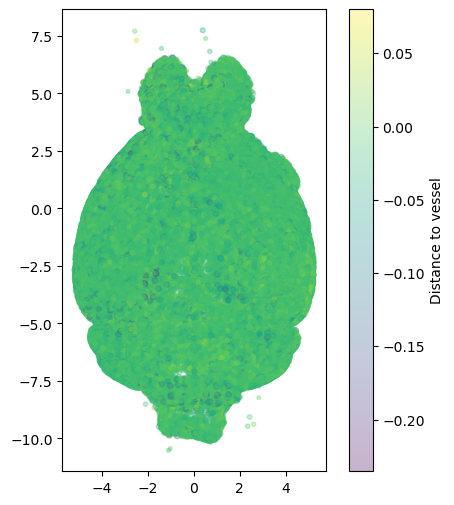

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["template_x"],
    df["template_y"],
    s=np.log10(df["nvoxels"]+1)*3,
    c=df["sdt_CD31"],
    alpha=0.3
)

plt.colorbar(label="Distance to vessel")
plt.gca().set_aspect("equal")
plt.show()

In [15]:
df.groupby("treatment").agg(
    n_plaques=("nvoxels","size"),
    median_size=("nvoxels","median"),
    mean_size=("nvoxels","mean"),
    median_dist=("sdt_CD31","median"),
    mean_dist=("sdt_CD31","mean")
)

,n_plaques,median_size,mean_size,median_dist,mean_dist
treatment,,,,,
Lecanemab,64117,486.0,15380.299187,-0.012586,-0.013439
PBS,79014,494.0,15331.478244,-0.012034,-0.011928


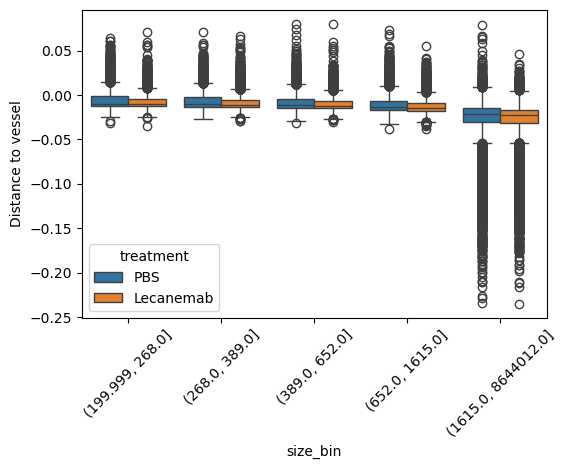

In [186]:
df['size_bin'] = pd.qcut(df['nvoxels'], 5)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='size_bin', y='sdt_CD31', hue='treatment')
plt.xticks(rotation=45)
plt.ylabel("Distance to vessel")
plt.show()

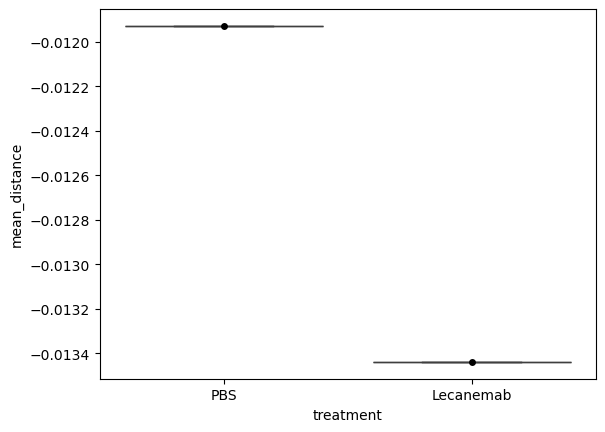

In [187]:
subject_stats = df.groupby(['subject','treatment']).agg(
    mean_distance=('sdt_CD31','mean'),
    median_distance=('sdt_CD31','median'),
    mean_size=('nvoxels','mean'),
    n_plaques=('nvoxels','size')
).reset_index()

sns.boxplot(data=subject_stats, x='treatment', y='mean_distance')
sns.stripplot(data=subject_stats, x='treatment', y='mean_distance', color='black')
plt.show()

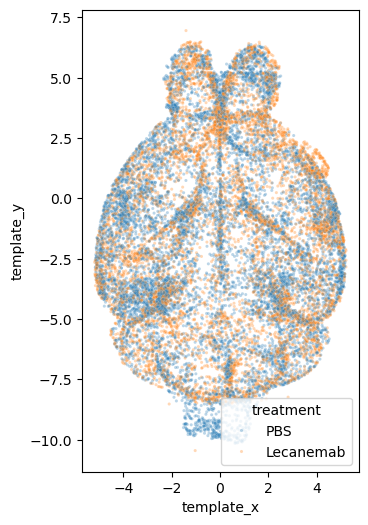

In [188]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df.sample(20000),
    x='template_x',
    y='template_y',
    hue='treatment',
    alpha=0.3,
    s=5
)
plt.gca().set_aspect('equal')
plt.show()

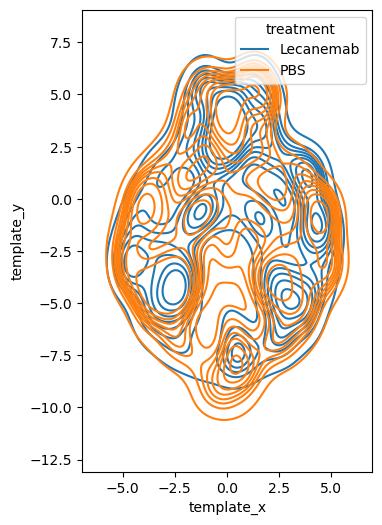

In [189]:
plt.figure(figsize=(6,6))
sns.kdeplot(
    data=df.sample(20000),
    x='template_x',
    y='template_y',
    hue='treatment'
)
plt.gca().set_aspect('equal')
plt.show()

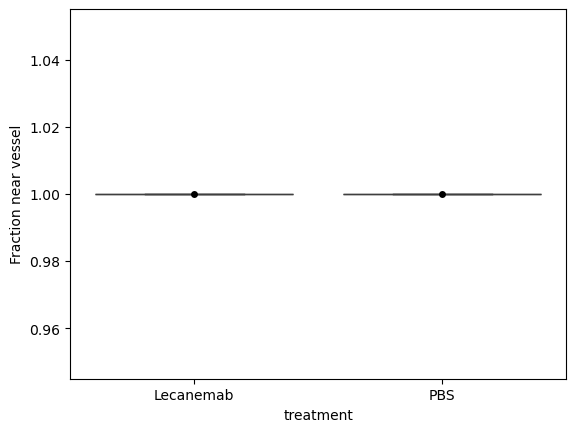

In [191]:
threshold = 20

df['near_vessel'] = df['sdt_CD31'] < threshold

near_stats = df.groupby(['subject','treatment'])['near_vessel'].mean().reset_index()

sns.boxplot(data=near_stats, x='treatment', y='near_vessel')
sns.stripplot(data=near_stats, x='treatment', y='near_vessel', color='black')
plt.ylabel("Fraction near vessel")
plt.show()

In [16]:
import numpy as np

voxel_vol = 1.6 * 1.6 * 2.75  # um^3

df = df.copy()
df["plaque_vol_um3"] = df["nvoxels"] * voxel_vol
df["equiv_diam_um"] = 2 * ((3 * df["plaque_vol_um3"]) / (4 * np.pi)) ** (1/3)

for thr in [10, 30, 50, 100, 300, 1000, 10000]:
    d = 2 * ((3 * (thr * voxel_vol)) / (4 * np.pi)) ** (1/3)
    print(f"{thr:>6} voxels -> {d:0.2f} um equiv diameter")

    10 voxels -> 5.12 um equiv diameter
    30 voxels -> 7.39 um equiv diameter
    50 voxels -> 8.76 um equiv diameter
   100 voxels -> 11.04 um equiv diameter
   300 voxels -> 15.92 um equiv diameter
  1000 voxels -> 23.78 um equiv diameter
 10000 voxels -> 51.23 um equiv diameter


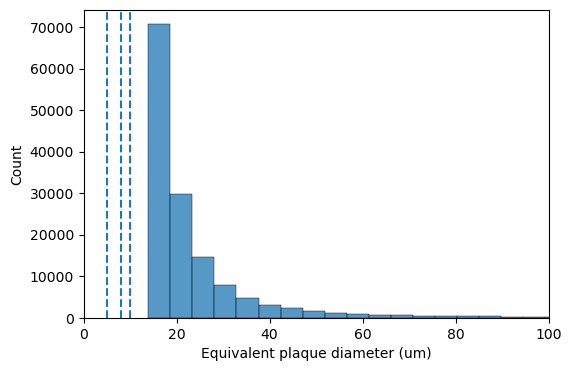

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df["equiv_diam_um"], bins=100)
plt.xlim((0,100))
plt.axvline(5, ls="--")
plt.axvline(8, ls="--")
plt.axvline(10, ls="--")
plt.xlabel("Equivalent plaque diameter (um)")
plt.show()

# old code below:

In [163]:
#make masks first:
plaques = df['nvoxels']< 

#sdt is signed distance of the plaque to vessel, adjusted by the vessel radius (assuming spherical)
#  so negative if inside or overlapping with vessel, and positive is distant from vessel
plaques_inside_vessels = df['sdt_CD31'] < 0  & plaques
plaques_outside_vessels = df['sdt_CD31'] > 0  & plaques

In [174]:
df_plaques_pbs = df.query("(nvoxels <2000 ) & treatment == 'PBS'")
df_plaques_leq = df.query("(nvoxels <2000 ) & treatment == 'Lecanemab'")

print(df_plaques_pbs.nvoxels.sum())
print(df_plaques_leq.nvoxels.sum())
print(29/36)

36619504.0
29574370.0
0.8055555555555556


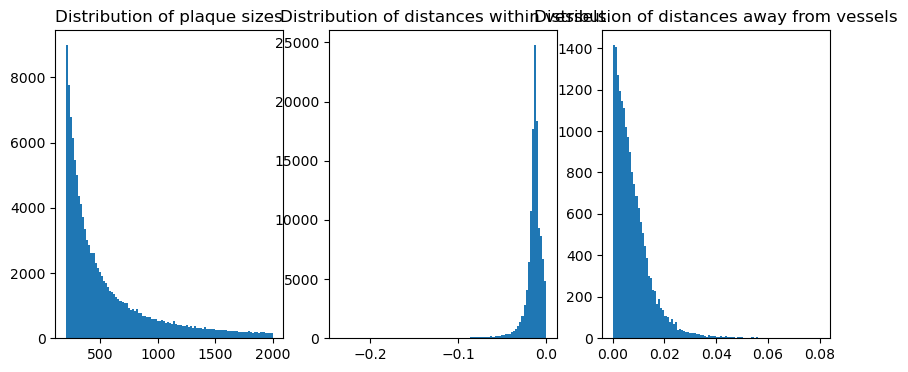

In [175]:
plaque_size = df[plaques]['nvoxels'].to_numpy()
signed_dist_to_vessels = df[plaques]['sdt_CD31'].to_numpy()


distances_inside_vessels = df[plaques_inside_vessels]['sdt_CD31'].to_numpy()
distances_outside_vessels = df[plaques_outside_vessels]['sdt_CD31'].to_numpy()

fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
axes[0].set_title("Distribution of plaque sizes")
axes[0].hist(plaque_size,bins=100);


axes[1].set_title("Distribution of distances within vessels")
axes[1].hist(distances_inside_vessels,bins=100);


axes[2].set_title("Distribution of distances away from vessels")
axes[2].hist(distances_outside_vessels,bins=100);

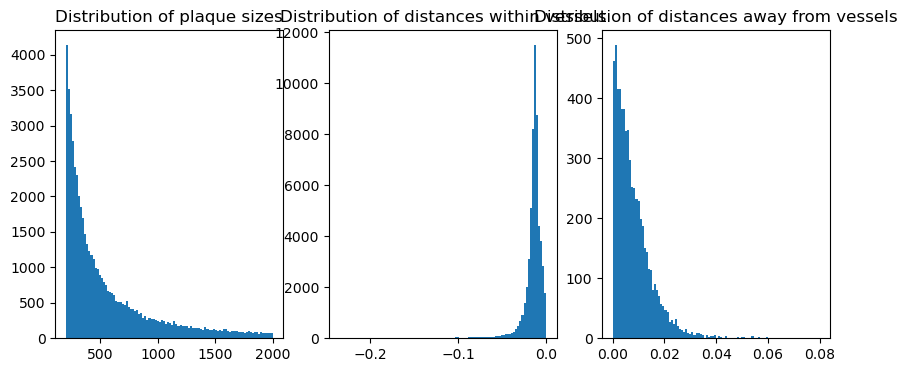

In [96]:
plaque_size = df[plaques]['nvoxels'].to_numpy()
signed_dist_to_vessels = df[plaques]['sdt_CD31'].to_numpy()


distances_inside_vessels = df[plaques_inside_vessels]['sdt_CD31'].to_numpy()
distances_outside_vessels = df[plaques_outside_vessels]['sdt_CD31'].to_numpy()

fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(10,4))
axes[0].set_title("Distribution of plaque sizes")
axes[0].hist(plaque_size,bins=100);


axes[1].set_title("Distribution of distances within vessels")
axes[1].hist(distances_inside_vessels,bins=100);


axes[2].set_title("Distribution of distances away from vessels")
axes[2].hist(distances_outside_vessels,bins=100);